In [1]:
%pip install composio-core composio-langchain

  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/501.2 kB ? eta -:--:--
   ----- ---------------------------------- 71.7/501.2 kB 2.0 MB/s eta 0:00:01
   ----------- ---------------------------- 143.4/501.2 kB 2.1 MB/s eta 0:00:01
   ---------------- ----------------------- 204.8/501.2 kB 1.6 MB/s eta 0:00:01
   ---------------------- ----------------- 286.7/501.2 kB 1.6 MB/s eta 0:00:01
   ---------------------------- ----------- 358.4/501.2 kB 1.7 MB/s eta 0:00:01
   ------------------------------- -------- 399.4/501.2 kB 1.6 MB/s eta 0:00:01
   ------------------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip show composio-core

Name: composio_core
Version: 0.7.21
Summary: [DEPRECATED] Core package to act as a bridge between composio platform and other services. Please use 'composio' instead.
Home-page: https://github.com/composiohq/composio
Author: Utkarsh
Author-email: utkarsh@composio.dev
License: 
Location: c:\Users\krimalpatel\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: aiohttp, click, fastapi, importlib-metadata, inflection, jsonref, jsonschema, paramiko, Pillow, pydantic, pyperclip, pysher, pyyaml, requests, rich, semver, sentry-sdk, uvicorn
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [6]:
import subprocess
subprocess.run(["python", "-m", "composio", "add", "gmail"])

CompletedProcess(args=['python', '-m', 'composio', 'add', 'gmail'], returncode=1)

In [7]:
from composio import ComposioToolSet, App

toolset = ComposioToolSet(api_key="ak_TD97cZypVukYwgmIvDeJ")

# Gmail connection link generate karo
request = toolset.initiate_connection(app=App.GMAIL)
print(f"🔗 Yahan jaao Gmail connect karne ke liye:")
print(f"   {request.redirectUrl}")

[2026-03-25 17:41:00,509][INFO] Actions cache is outdated, refreshing cache...


🔗 Yahan jaao Gmail connect karne ke liye:
   https://backend.composio.dev/api/v3/s/ppnsYT0F


In [3]:
%pip uninstall composio-core composio-langchain composio-openai -y

Found existing installation: composio_core 0.7.21
Uninstalling composio_core-0.7.21:
  Successfully uninstalled composio_core-0.7.21
Found existing installation: composio-langchain 0.11.3
Uninstalling composio-langchain-0.11.3:
  Successfully uninstalled composio-langchain-0.11.3
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install composio-core==0.7.4 composio-langchain==0.7.4

   ---------------------------------------- 0.0/481.6 kB ? eta -:--:--
   - -------------------------------------- 20.5/481.6 kB ? eta -:--:--
   - -------------------------------------- 20.5/481.6 kB ? eta -:--:--
   --- ----------------------------------- 41.0/481.6 kB 281.8 kB/s eta 0:00:02
   --- ----------------------------------- 41.0/481.6 kB 281.8 kB/s eta 0:00:02
   ------- ------------------------------- 92.2/481.6 kB 375.8 kB/s eta 0:00:02
   ------------ ------------------------- 163.8/481.6 kB 579.6 kB/s eta 0:00:01
   ------------------- ------------------ 245.8/481.6 kB 718.0 kB/s eta 0:00:01
   --------------------- ---------------- 276.5/481.6 kB 776.2 kB/s eta 0:00:01
   ----------------------------- -------- 368.6/481.6 kB 849.3 kB/s eta 0:00:01
   ---------------------------------- --- 440.3/481.6 kB 949.4 kB/s eta 0:00:01
   -------------------------------------- 481.6/481.6 kB 942.8 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from composio_langchain import ComposioToolSet, Action
import os

toolset = ComposioToolSet(api_key="YOUR_COMPOSIO_API_KEY")

gmail_tools = toolset.get_tools(actions = [
    Action.GMAIL_SEND_EMAIL,
    Action.GMAIL_CREATE_EMAIL_DRAFT
])

print(f"✅ Gmail tools ready: {len(gmail_tools)} tools mili!")

for tool in gmail_tools:
    print(f"  -> {tool.name}")

✅ Gmail tools ready: 2 tools mili!
  -> GMAIL_CREATE_EMAIL_DRAFT
  -> GMAIL_SEND_EMAIL


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

# ✅ Seedha set karo — .env ki zaroorat nahi
os.environ["GROQ_API_KEY"]     = "YOUR_GROQ_API_KEY"
os.environ["TAVILY_API_KEY"]   = "YOUR_TAVILY_API_KEY"
os.environ["COMPOSIO_API_KEY"] = "YOUR_COMPOSIO_API_KEY"

# Verify karo
print("GROQ     :", os.environ["GROQ_API_KEY"][:10],     "...")
print("TAVILY   :", os.environ["TAVILY_API_KEY"][:10],   "...")
print("COMPOSIO :", os.environ["COMPOSIO_API_KEY"][:10], "...")
print("✅ All keys loaded!")

GROQ     : gsk_9MPlz5 ...
TAVILY   : tvly-dev-2 ...
COMPOSIO : ak_TD97cZy ...
✅ All keys loaded!


TAVILY SEARCH

In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq
import os 

search_tool = TavilySearchResults(
    max_results=5,
    api_key = os.environ["TAVILY_API_KEY"]
)

print("🔍 Searching real jobs...")
results = search_tool.invoke(
    "Python Developer jobs in Ahmedabad India 2025"
)

print(f"\n✅ Found {len(results)} results!\n")
for i,result in enumerate(results):
    print(f"Result {i+1}:")
    print(f"  Title : {result['title']}")
    print(f"  URL   : {result['url']}")
    print(f"  Info  : {result['content'][:100]}...")
    print()
    


C:\Users\krimalpatel\AppData\Local\Temp\ipykernel_1476\3083271562.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(


🔍 Searching real jobs...

✅ Found 5 results!

Result 1:
  Title : 498 python jobs in Ahmedabad, March 2026 - Glassdoor
  URL   : https://www.glassdoor.co.in/Job/ahmedabad-python-jobs-SRCH_IL.0,9_IC2935226_KO10,16.htm
  Info  : 498 Python jobs in Ahmedabad ; Arihant AI · Python Developer Internship ; Sanskar Technolab Pvt Ltd....

Result 2:
  Title : 1,000+ Hiring For Python jobs in Ahmedabad - LinkedIn
  URL   : https://in.linkedin.com/jobs/hiring-for-python-jobs-ahmedabad-gj?trk=guest_job_details_jd_jserp_more_jobs_link
  Info  : #### Tata Electronics

### Data processing

#### Moksh Tech

### Python Django Developer

#### MindI...

Result 3:
  Title : 156 Python Developer jobs in Ahmedabad - LinkedIn
  URL   : https://in.linkedin.com/jobs/python-developer-jobs-ahmedabad
  Info  : #### Turing

### Python Developer

#### Talkwisely

### Backend Engineer

#### Jetbro

### Web Appli...

Result 4:
  Title : Python Jobs In Ahmedabad - Naukri.com
  URL   : https://www.naukri.com/python-jobs

In [11]:
from typing import TypedDict, Annotated
import operator

class JobState(TypedDict):

    # ── User Input ─────────────────────────────
    job_role     : str    # "Python Developer"
    user_name    : str    # "Krimal Patel"
    user_resume  : str    # resume text

    # ── Research Subgraph Output ───────────────
    job_listings : list   # real jobs from Tavily
    company_info : list   # company details

    # ── Content Subgraph Output ────────────────
    tailored_resumes : list  # one per job
    cover_letters    : list  # one per job

    # ── Human Approval ─────────────────────────
    human_approved : bool
    approved_jobs  : list

    # ── Apply Subgraph Output ──────────────────
    emails_sent  : Annotated[list, operator.add]
    tracker_path : str

print("✅ JobState defined!")

✅ JobState defined!


LLM CALLING

In [13]:
from langchain_groq import ChatGroq
import json

llm = ChatGroq(
    model = "llama-3.1-8b-instant",
    temperature= 0
)

def job_search_node(state: JobState) -> dict:
    print("🔍 Searching real jobs with Tavily...")

    query = f"{state['job_role']} jobs in india 2025"
    results = search_tool.invoke(query)

    print(f"✅ Found {len(results)} raw results!")

    raw_text = "\n\n".join([
        f"Title: {r['title']}\nURL: {r['url']}\nContent: {r['content'][:300]}"
        for r in results
    ])

    prompt = f"""
    Extract job listings from the following search results.
    Return a JSON array with exactly this format:
    [
        {{
            "title"   : "job title",
            "company" : "company name",
            "location": "city or Remote",
            "email"   : "hr@company.com",
            "url"     : "job url"
        }}
    ]

    Extract maximum 3 jobs only.
    If email is not found use "careers@company.com"
    Return ONLY the JSON array — no extra text!

    Search Results:
    {raw_text}
    
    """

    response = llm.invoke(prompt).content

    try:

        clean= response.strip()
        if "```" in clean:
            clean = clean.split("```")[1]
            if clean.startswith("json"):
                clean = clean[4:]

        jobs = json.loads(clean)
        print(f"   ✅ Extracted {len(jobs)} structured jobs!")

    except Exception as e:
        print(f"   ⚠️ JSON parse error — using fallback: {e}")
        jobs = [
            {
                "title" : results[0]["title"][:50],
                "company":"tech company",
                "location" : "India",
                "email" : "careers@company.com",
                "url" : results[0]["url"]
            }
        ]

    for i , job in enumerate(jobs):
        print(f"\n   Job {i+1}:")
        print(f"   Title   : {job['title']}")
        print(f"   Company : {job['company']}")
        print(f"   Location: {job['location']}")


    return {"job_listings" : jobs}

print("✅ Real job search node ready!")   


✅ Real job search node ready!


In [14]:
test_state = {
    "job_role"        : "Python Developer",
    "user_name"       : "Krimal Patel",
    "user_resume"     : "Python | LangChain | LangGraph",
    "job_listings"    : [],
    "company_info"    : [],
    "tailored_resumes": [],
    "cover_letters"   : [],
    "human_approved"  : False,
    "approved_jobs"   : [],
    "emails_sent"     : [],
    "tracker_path"    : ""
}

result = job_search_node(test_state)

print("\n📋 Final Jobs:")
for job in result["job_listings"]:
    print(f"   → {job['title']} at {job['company']}")

🔍 Searching real jobs with Tavily...
✅ Found 5 raw results!
   ✅ Extracted 3 structured jobs!

   Job 1:
   Title   : Python Developer Jobs in MNC Companies 2025
   Company : Pitchnhire
   Location: Remote

   Job 2:
   Title   : Python Developer Jobs
   Company : Foundit
   Location: India

   Job 3:
   Title   : Python Developer
   Company : Quant Global
   Location: Noida

📋 Final Jobs:
   → Python Developer Jobs in MNC Companies 2025 at Pitchnhire
   → Python Developer Jobs at Foundit
   → Python Developer at Quant Global


SMTPLIB CELL

In [16]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

# ── Gmail Credentials ───────────────────────────────────────
SENDER_EMAIL    = "pateljimi53@gmail.com"      # ← apna gmail
SENDER_PASSWORD = "afig zhmg matz khvb"       # ← app password

# ── Real Gmail Send Function ────────────────────────────────
def send_real_email(to: str, subject: str, body: str) -> str:
    """Send real email via Gmail SMTP"""
    try:
        # Email banao
        msg             = MIMEMultipart()
        msg["From"]     = SENDER_EMAIL
        msg["To"]       = to
        msg["Subject"]  = subject
        msg.attach(MIMEText(body, "plain"))

        # Gmail SMTP se bhejo
        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        server.login(SENDER_EMAIL, SENDER_PASSWORD)
        server.sendmail(SENDER_EMAIL, to, msg.as_string())
        server.quit()

        print(f"      ✅ Email sent to {to}!")
        return f"Email sent to {to} successfully!"

    except Exception as e:
        print(f"      ❌ Error: {str(e)}")
        return f"Failed: {str(e)}"


# ── Real Send Applications Node ─────────────────────────────
def send_applications_node(state: JobState) -> dict:
    print("📨 Sending real applications...")

    sent = []

    for i, job in enumerate(state["approved_jobs"]):
        print(f"\n   ✉️  Applying to {job['company']}...")

        result = send_real_email(
            to      = job["email"],
            subject = f"Application for {job['title']} — {state['user_name']}",
            body    = state["cover_letters"][i]
        )

        sent.append(f"{job['company']} → {result}")

    print("\n   ✅ All applications sent!")
    return {"emails_sent": sent}


print("✅ Real Gmail node ready!")

✅ Real Gmail node ready!


In [18]:
# ✅ Test — apne aap ko bhejo pehle!
result = send_real_email(
    to      = "palak.pithadiya20@gmail.com",  # ← apna email daalo
    subject = "Test — AI Job Automator",
    body    = "Hello Palak! This is the test email which i send you from job ai automator agent! 🚀"
)
print(result)


      ✅ Email sent to palak.pithadiya20@gmail.com!
Email sent to palak.pithadiya20@gmail.com successfully!


REAL SEND APPLICATION NODE

In [19]:
# ── Real Send Applications Node ─────────────────────────────
def send_applications_node(state: JobState) -> dict:
    print("📨 Sending real applications...")

    sent = []

    for i, job in enumerate(state["approved_jobs"]):
        print(f"\n   ✉️  Applying to {job['company']}...")

        result = send_real_email(
            to      = job["email"],
            subject = f"Application for {job['title']} — {state['user_name']}",
            body    = state["cover_letters"][i]
        )

        sent.append(f"{job['company']} → {result}")

    print("\n   ✅ All applications sent!")
    return {"emails_sent": sent}

print("✅ Send applications node ready!")

✅ Send applications node ready!


REAL SAVE TRACKER NODE

In [20]:
import pandas as pd
import os

os.makedirs("outputs/cover_letters", exist_ok=True)

def save_tracker_node(state: JobState) -> dict:
    print("📊 Saving to Excel tracker...")

    data = []

    for i, job in enumerate(state["approved_jobs"]):

        # Cover letter file me save karo
        letter_file = f"outputs/cover_letters/{i+1}_{job['company']}.txt"
        with open(letter_file, "w", encoding="utf-8") as f:
            f.write(f"Company : {job['company']}\n")
            f.write(f"Role    : {job['title']}\n")
            f.write(f"Email   : {job['email']}\n")
            f.write("="*50 + "\n\n")
            f.write(state["cover_letters"][i])
        print(f"   📝 Cover letter saved → {letter_file}")

        data.append({
            "Company"          : job["company"],
            "Role"             : job["title"],
            "Location"         : job["location"],
            "Email"            : job["email"],
            "Status"           : "Applied ✅",
            "Cover Letter File": letter_file
        })

    # Excel save karo
    df   = pd.DataFrame(data)
    path = "outputs/applications.xlsx"

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        df.to_excel(writer, index=False, sheet_name="Applications")
        worksheet = writer.sheets["Applications"]
        worksheet.column_dimensions["A"].width = 15
        worksheet.column_dimensions["B"].width = 25
        worksheet.column_dimensions["C"].width = 15
        worksheet.column_dimensions["D"].width = 30
        worksheet.column_dimensions["E"].width = 12
        worksheet.column_dimensions["F"].width = 40

    print(f"\n   ✅ Excel saved → {path}")
    return {"tracker_path": path}

print("✅ Save tracker node ready!")

✅ Save tracker node ready!


COMPANY RESEARCH NODE

In [ ]:
def company_research_node(state: JobState) -> dict:
    print("🏢 Researching companies...")

    companies = []

    for job in state["job_listings"]:
        print(f"   🔍 Researching {job['company']}...")

        # Tavily se company research karo
        results = search_tool.invoke(
            f"{job['company']} company culture work environment India"
        )

        raw = " ".join([r["content"][:200] for r in results[:2]])

        prompt = f"""
        Based on this info about {job['company']}:
        {raw}

        Return a JSON object:
        {{
            "name"   : "{job['company']}",
            "about"  : "one line about company",
            "culture": "work culture description",
            "size"   : "company size"
        }}

        Return ONLY JSON — no extra text!
        """

        response = llm.invoke(prompt).content

        try:
            clean = response.strip()
            if "```" in clean:
                clean = clean.split("```")[1]
                if clean.startswith("json"):
                    clean = clean[4:]
            info = json.loads(clean)
        except:
            info = {
                "name"   : job["company"],
                "about"  : f"{job['company']} is a tech company.",
                "culture": "Professional and collaborative",
                "size"   : "Unknown"
            }

        companies.append(info)
        print(f"   ✅ Researched: {job['company']}")

    return {"company_info": companies}

print("✅ Company research node ready!")

✅ Company research node ready!


HUMAN APPROVAL NODE 

In [22]:
# ── Global Approval Variable ────────────────────────────────
USER_APPROVAL = True   # ← True = apply, False = cancel

def human_approval_node(state: JobState) -> dict:
    print("\n" + "="*50)
    print("🛑 HUMAN APPROVAL REQUIRED")
    print("="*50)

    print(f"\nFound {len(state['job_listings'])} real jobs:\n")
    for i, job in enumerate(state["job_listings"]):
        print(f"  {i+1}. {job['title']}")
        print(f"     Company : {job['company']}")
        print(f"     Location: {job['location']}")
        print(f"     Email   : {job['email']}")
        print()

    if USER_APPROVAL:
        print("✅ Auto Approved!")
        return {
            "human_approved": True,
            "approved_jobs" : state["job_listings"]
        }
    else:
        print("❌ Cancelled!")
        return {
            "human_approved": False,
            "approved_jobs" : []
        }

def route_after_approval(state: JobState) -> str:
    return "apply" if state["human_approved"] else "cancelled"

print("✅ Human approval node ready!")

✅ Human approval node ready!


TAILOR RESUME NODE

In [23]:
# ── Node: Tailor Resume ─────────────────────────────────────
def tailor_resume_node(state: JobState) -> dict:
    print("📄 Tailoring resumes...")

    tailored_resumes = []

    for i, job in enumerate(state["job_listings"]):
        print(f"   ✍️  Tailoring for {job['company']}...")

        prompt = f"""
        Tailor this resume for the following job:

        Job Title   : {job['title']}
        Company     : {job['company']}
        Company Info: {state['company_info'][i]}

        Original Resume:
        {state['user_resume']}

        Write only a short tailored summary section
        of 3-4 lines. Professional tone.
        """

        result = llm.invoke(prompt).content
        tailored_resumes.append(result)
        print(f"   ✅ Done: {job['company']}")

    print("   ✅ All resumes tailored!")
    return {"tailored_resumes": tailored_resumes}

print("✅ Tailor resume node ready!")

✅ Tailor resume node ready!


COVER LETTER NODE

In [24]:
# ── Node: Cover Letter Writer ───────────────────────────────
def cover_letter_node(state: JobState) -> dict:
    print("✍️  Writing cover letters...")

    cover_letters = []

    for i, job in enumerate(state["job_listings"]):
        print(f"   📝 Writing for {job['company']}...")

        prompt = f"""
        Write a professional cover letter for:

        Applicant Name : {state['user_name']}
        Job Title      : {job['title']}
        Company        : {job['company']}
        Company Culture: {state['company_info'][i].get('culture', '')}

        Tailored Resume Summary:
        {state['tailored_resumes'][i]}

        Rules:
        - Keep it under 150 words
        - Professional tone
        - Start with Dear Hiring Manager
        - End with Thank you
        - Sign with applicant name
        """

        letter = llm.invoke(prompt).content
        cover_letters.append(letter)
        print(f"   ✅ Done: {job['company']}")

    print("   ✅ All cover letters written!")
    return {"cover_letters": cover_letters}

print("✅ Cover letter node ready!")

✅ Cover letter node ready!


SUBGRAPH

In [25]:
from langgraph.graph import StateGraph, START, END

# ── Research Subgraph ───────────────────────────────────────
def build_research_graph():
    graph = StateGraph(JobState)

    graph.add_node("job_search",       job_search_node)
    graph.add_node("company_research", company_research_node)

    graph.add_edge(START,              "job_search")
    graph.add_edge("job_search",       "company_research")
    graph.add_edge("company_research", END)

    return graph.compile()

# ── Content Subgraph ────────────────────────────────────────
def build_content_graph():
    graph = StateGraph(JobState)

    graph.add_node("tailor_resume", tailor_resume_node)
    graph.add_node("cover_letter",  cover_letter_node)

    graph.add_edge(START,           "tailor_resume")
    graph.add_edge("tailor_resume", "cover_letter")
    graph.add_edge("cover_letter",  END)

    return graph.compile()

# ── Apply Subgraph ──────────────────────────────────────────
def build_apply_graph():
    graph = StateGraph(JobState)

    graph.add_node("send_applications", send_applications_node)
    graph.add_node("save_tracker",      save_tracker_node)

    graph.add_edge(START,               "send_applications")
    graph.add_edge("send_applications", "save_tracker")
    graph.add_edge("save_tracker",      END)

    return graph.compile()

# ── Compile teeno subgraphs ─────────────────────────────────
research_graph = build_research_graph()
content_graph  = build_content_graph()
apply_graph    = build_apply_graph()

print("✅ Research Subgraph compiled!")
print("✅ Content Subgraph compiled!")
print("✅ Apply Subgraph compiled!")
print("✅ All 3 subgraphs ready!")

✅ Research Subgraph compiled!
✅ Content Subgraph compiled!
✅ Apply Subgraph compiled!
✅ All 3 subgraphs ready!


MAIN GRAPH

In [26]:
from langgraph.checkpoint.memory import MemorySaver

# ── Supervisor Node ─────────────────────────────────────────
def supervisor_node(state: JobState) -> dict:
    print("\n🤖 Supervisor: Starting AI Job Application...")
    print(f"   Job Role : {state['job_role']}")
    print(f"   Applicant: {state['user_name']}")
    return {}

# ── Run Research Node ───────────────────────────────────────
def run_research_node(state: JobState) -> dict:
    print("\n📌 Running Research Subgraph...")
    result = research_graph.invoke(state)
    return {
        "job_listings": result["job_listings"],
        "company_info": result["company_info"]
    }

# ── Run Content Node ────────────────────────────────────────
def run_content_node(state: JobState) -> dict:
    print("\n📌 Running Content Subgraph...")
    result = content_graph.invoke(state)
    return {
        "tailored_resumes": result["tailored_resumes"],
        "cover_letters"   : result["cover_letters"]
    }

# ── Run Apply Node ──────────────────────────────────────────
def run_apply_node(state: JobState) -> dict:
    print("\n📌 Running Apply Subgraph...")
    result = apply_graph.invoke(state)
    return {
        "emails_sent" : result["emails_sent"],
        "tracker_path": result["tracker_path"]
    }

# ── Cancelled Node ──────────────────────────────────────────
def cancelled_node(state: JobState) -> dict:
    print("\n❌ Cancelled — no emails sent!")
    return {}

# ── Build Main Graph ────────────────────────────────────────
def build_main_graph():
    memory = MemorySaver()
    graph  = StateGraph(JobState)

    # Nodes add karo
    graph.add_node("supervisor",     supervisor_node)
    graph.add_node("run_research",   run_research_node)
    graph.add_node("run_content",    run_content_node)
    graph.add_node("human_approval", human_approval_node)
    graph.add_node("run_apply",      run_apply_node)
    graph.add_node("cancelled",      cancelled_node)

    # Edges add karo
    graph.add_edge(START,            "supervisor")
    graph.add_edge("supervisor",     "run_research")
    graph.add_edge("run_research",   "run_content")
    graph.add_edge("run_content",    "human_approval")

    # Conditional edge
    graph.add_conditional_edges(
        "human_approval",
        route_after_approval,
        {
            "apply"    : "run_apply",
            "cancelled": "cancelled"
        }
    )

    graph.add_edge("run_apply",  END)
    graph.add_edge("cancelled",  END)

    # Compile with checkpointing
    return graph.compile(checkpointer=memory)

# ── Compile ─────────────────────────────────────────────────
app = build_main_graph()
print("✅ Main Graph compiled!")
print("✅ Checkpointing enabled!")

✅ Main Graph compiled!
✅ Checkpointing enabled!


RUN

In [27]:
# ── Initial State ───────────────────────────────────────────
initial_state = {
    "job_role"        : "Python Developer",
    "user_name"       : "Krimal Patel",
    "user_resume"     : """
        Krimal Patel | Python Developer
        Skills    : Python, FastAPI, LangChain, LangGraph, SQL
        Experience: 2 years building AI applications
        Education : B.Tech Computer Science
        Projects  : AI Data Analyst, Job Automator
    """,
    "job_listings"    : [],
    "company_info"    : [],
    "tailored_resumes": [],
    "cover_letters"   : [],
    "human_approved"  : False,
    "approved_jobs"   : [],
    "emails_sent"     : [],
    "tracker_path"    : ""
}

# ── Config ──────────────────────────────────────────────────
config = {"configurable": {"thread_id": "mcp_run_1"}}

# ── RUN! ────────────────────────────────────────────────────
print("🚀 AI Job Application Automator (MCP Version) Starting...\n")
print("="*50)

result = app.invoke(initial_state, config=config)

# ── Final Results ───────────────────────────────────────────
print("\n" + "="*50)
print("🎉 FINAL RESULTS")
print("="*50)

if result["human_approved"]:

    print(f"\n✅ Real Emails Sent : {len(result['emails_sent'])}")
    print(f"✅ Tracker Saved   : {result['tracker_path']}")
    print(f"✅ Cover Letters   : outputs/cover_letters/")

    print("\n📧 Applications Sent:")
    for email in result["emails_sent"]:
        print(f"   → {email}")

    print("\n📝 Cover Letters:")
    for i, letter in enumerate(result["cover_letters"]):
        job = result["job_listings"][i]
        print(f"\n   --- {job['company']} ---")
        print(f"   {letter[:150]}...")

    print("\n📊 Check Excel tracker:")
    print(f"   → {result['tracker_path']}")

else:
    print("\n❌ Process cancelled — no emails sent!")

print("\n" + "="*50)
print("✅ MCP Version Complete!")
print("="*50)

🚀 AI Job Application Automator (MCP Version) Starting...


🤖 Supervisor: Starting AI Job Application...
   Job Role : Python Developer
   Applicant: Krimal Patel

📌 Running Research Subgraph...
🔍 Searching real jobs with Tavily...
✅ Found 5 raw results!
   ✅ Extracted 3 structured jobs!

   Job 1:
   Title   : Python Developer
   Company : TCS
   Location: India

   Job 2:
   Title   : Python Developer
   Company : Infosys
   Location: India

   Job 3:
   Title   : Python Developer
   Company : Amazon
   Location: India
🏢 Researching companies...
   🔍 Researching TCS...
   ✅ Researched: TCS
   🔍 Researching Infosys...
   ✅ Researched: Infosys
   🔍 Researching Amazon...
   ✅ Researched: Amazon

📌 Running Content Subgraph...
📄 Tailoring resumes...
   ✍️  Tailoring for TCS...
   ✅ Done: TCS
   ✍️  Tailoring for Infosys...
   ✅ Done: Infosys
   ✍️  Tailoring for Amazon...
   ✅ Done: Amazon
   ✅ All resumes tailored!
✍️  Writing cover letters...
   📝 Writing for TCS...
   ✅ Done: TCS
   📝 W

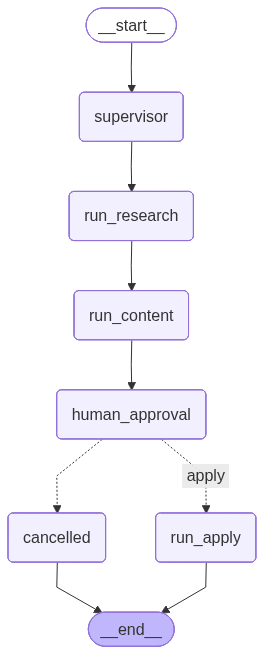

In [28]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())